In [5]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import py3Dmol

# Charger le fichier mol
mol = Chem.MolFromMolFile("morphine.mol", removeHs=False)

# Infos de base
print("Formula:", rdMolDescriptors.CalcMolFormula(mol))
print("Molecular weight:", Descriptors.MolWt(mol))
print("Number of atoms:", mol.GetNumAtoms())
print("Number of bonds:", mol.GetNumBonds())
print("the symbol of the atoms in the molecule:", [atom.GetSymbol() for atom in mol.GetAtoms()])
print("Number of nitrogen atoms:", len([mol.GetAtomWithIdx(i).GetSymbol() for i in range(mol.GetNumAtoms()) if mol.GetAtomWithIdx(i).GetSymbol() == 'N']))
print("Number of oxygen atoms:", len([mol.GetAtomWithIdx(i).GetSymbol() for i in range(mol.GetNumAtoms()) if mol.GetAtomWithIdx(i).GetSymbol() == 'O']))
print('Number of carbon atoms:', len([mol.GetAtomWithIdx(i).GetSymbol() for i in range(mol.GetNumAtoms()) if mol.GetAtomWithIdx(i).GetSymbol() == 'C'   ]))
# Visualisation 3D
mol_block = Chem.MolToMolBlock(mol)
viewer = py3Dmol.view(width=600, height=500)
viewer.addModel(mol_block, "mol")
viewer.setStyle({"stick": {}, "sphere": {"scale": 0.25}})
viewer.setStyle({"elem": "N"}, {"stick": {"color": "purple"}, "sphere": {"color": "purple", "scale": 0.25}})

viewer.setBackgroundColor("black")
viewer.zoomTo()
viewer.show()

Formula: C17H19NO3
Molecular weight: 285.34299999999956
Number of atoms: 40
Number of bonds: 44
the symbol of the atoms in the molecule: ['C', 'N', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'O', 'C', 'O', 'C', 'C', 'O', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H']
Number of nitrogen atoms: 1
Number of oxygen atoms: 3
Number of carbon atoms: 17


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

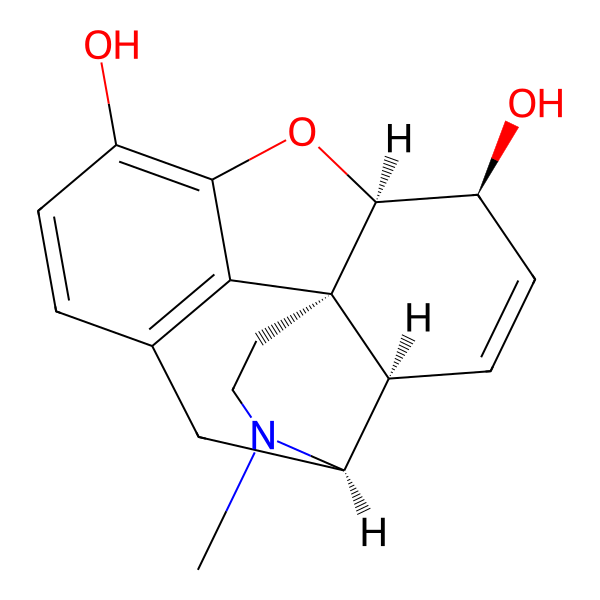

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem

mol = Chem.MolFromMolFile("morphine.mol")
AllChem.Compute2DCoords(mol)

# Affichage direct dans le notebook
Draw.MolToImage(mol, size=(600, 600))

In [13]:
from rdkit.Chem import Descriptors, rdMolDescriptors 
Descriptors.MolWt(mol)  # Calcul du poids moléculaire


285.343

In [20]:
from rdkit.Chem import Descriptors, rdMolDescriptors




logP  =  Descriptors.MolLogP(mol)
if logP > 0 : 
    print("The molecule is hydrophobic or the molecule is non-polar")
elif logP == 0 : 
    print("The molecule is neutral")
else : 
    print("The molecule is hydrophilic or the molecule is polar")


The molecule is hydrophobic or the molecule is non-polar


In [21]:
Descriptors.NumRotatableBonds(mol)  # Calcul du nombre de liaisons rotatives


0

In [22]:
smiles = Chem.MolToSmiles(mol)
print(smiles)

CN1CC[C@]23c4c5ccc(O)c4O[C@H]2[C@@H](O)C=C[C@H]3[C@H]1C5


In [23]:
mw = Descriptors.MolWt(mol )
print("Molecular weight:", mw)



Molecular weight: 285.343


In [24]:
molecules = {
    "Water": "O",
    "Methane": "C",
    "Ethanol": "CCO",
    "Acetic acid": "CC(=O)O",
    "Benzene": "c1ccccc1",
    "Toluene": "Cc1ccccc1",
    "Phenol": "Oc1ccccc1",
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine": "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Glucose": "OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O",
    "Morphine": "CN1CC[C@]23c4c5ccc(O)c4O[C@H]2[C@@H](O)C=C[C@H]3[C@H]1C5",
    "Cholesterol": "CC(C)CCCC(C)C1CCC2C1(CCC3C2CC=C4C3(CCC(C4)O)C)C",
    "Nicotine": "CN1CCC[C@H]1c1cccnc1",
    "Vitamin C": "OC[C@H](O)[C@H]1OC(=O)C(O)=C1O",
    "Dopamine": "NCCc1ccc(O)c(O)c1",
    "Serotonin": "NCCc1c[nH]c2ccc(O)cc12",
    "Adrenaline": "CNC[C@H](O)c1ccc(O)c(O)c1",
    "Cortisone": "CC12CCC(=O)C=C1CCC1C2C(=O)CC2(C)C1CCC2(O)C(=O)CO",
    "TNT": "Cc1c(cc(cc1[N+](=O)[O-])[N+](=O)[O-])[N+](=O)[O-]"
}
mol_list = []
for name , molecules in molecules.items() : 
    mol = Chem.MolFromSmiles(molecules)
    mol_list.append((name, mol))
    print(f"{name}: {Chem.MolToSmiles(mol)}")

Water: O
Methane: C
Ethanol: CCO
Acetic acid: CC(=O)O
Benzene: c1ccccc1
Toluene: Cc1ccccc1
Phenol: Oc1ccccc1
Aspirin: CC(=O)Oc1ccccc1C(=O)O
Caffeine: Cn1c(=O)c2c(ncn2C)n(C)c1=O
Paracetamol: CC(=O)Nc1ccc(O)cc1
Ibuprofen: CC(C)Cc1ccc(C(C)C(=O)O)cc1
Glucose: OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O
Morphine: CN1CC[C@]23c4c5ccc(O)c4O[C@H]2[C@@H](O)C=C[C@H]3[C@H]1C5
Cholesterol: CC(C)CCCC(C)C1CCC2C3CC=C4CC(O)CCC4(C)C3CCC12C
Nicotine: CN1CCC[C@H]1c1cccnc1
Vitamin C: O=C1O[C@H]([C@@H](O)CO)C(O)=C1O
Dopamine: NCCc1ccc(O)c(O)c1
Serotonin: NCCc1c[nH]c2ccc(O)cc12
Adrenaline: CNC[C@H](O)c1ccc(O)c(O)c1
Cortisone: CC12CCC(=O)C=C1CCC1C2C(=O)CC2(C)C1CCC2(O)C(=O)CO
TNT: Cc1c([N+](=O)[O-])cc([N+](=O)[O-])cc1[N+](=O)[O-]


In [29]:
molecules = {
    "Water": "O",
    "Methane": "C",
    "Ethanol": "CCO",
    "Acetic acid": "CC(=O)O",
    "Benzene": "c1ccccc1",
    "Toluene": "Cc1ccccc1",
    "Phenol": "Oc1ccccc1",
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine": "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Glucose": "OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O",
    "Morphine": "CN1CC[C@]23c4c5ccc(O)c4O[C@H]2[C@@H](O)C=C[C@H]3[C@H]1C5",
    "Cholesterol": "CC(C)CCCC(C)C1CCC2C1(CCC3C2CC=C4C3(CCC(C4)O)C)C",
    "Nicotine": "CN1CCC[C@H]1c1cccnc1",
    "Vitamin C": "OC[C@H](O)[C@H]1OC(=O)C(O)=C1O",
    "Dopamine": "NCCc1ccc(O)c(O)c1",
    "Serotonin": "NCCc1c[nH]c2ccc(O)cc12",
    "Adrenaline": "CNC[C@H](O)c1ccc(O)c(O)c1",
    "Cortisone": "CC12CCC(=O)C=C1CCC1C2C(=O)CC2(C)C1CCC2(O)C(=O)CO",
    "TNT": "Cc1c(cc(cc1[N+](=O)[O-])[N+](=O)[O-])[N+](=O)[O-]"
}
for name , molecules in molecules.items() :
    mol = Chem.MolFromSmiles(molecules)
  
    AllChem.Compute2DCoords(mol)
    image = Draw.MolToImage(mol , size= (300 , 300))
    print(f"Generated image for {name}")
    print(image)
    
    image.save(f"{name}.png")
    print(f"Saved image for {name} as {name}.png")

Generated image for Water
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=300x300 at 0x260968D07D0>
Saved image for Water as Water.png
Generated image for Methane
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=300x300 at 0x260968D0550>
Saved image for Methane as Methane.png
Generated image for Ethanol
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=300x300 at 0x260968D07D0>
Saved image for Ethanol as Ethanol.png
Generated image for Acetic acid
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=300x300 at 0x260968D0550>
Saved image for Acetic acid as Acetic acid.png
Generated image for Benzene
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=300x300 at 0x260968D07D0>
Saved image for Benzene as Benzene.png
Generated image for Toluene
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=300x300 at 0x260968D0550>
Saved image for Toluene as Toluene.png
Generated image for Phenol
<PIL.PngImagePlugin.PngImageFile image mode=RGB size=300x300 at 0x260968D0410>
Saved image 

In [3]:
import pandas as pd 
df = pd.read_excel(r"C:\Users\pc\Desktop\project\tutorial_rdkit\Heteroaromatics.xlsx")

print(df.head(5))


         Smiles
0    CN1C=CC=C1
1     C1=CC=CN1
2   C1=CN=CC=C1
3  CC1=NC=CC=C1
4  CC1=CC=NC=C1


**Generating molecular objects from smiles**

,Smiles,mol
0,CN1C=CC=C1,
1,C1=CC=CN1,
2,C1=CN=CC=C1,
3,CC1=NC=CC=C1,
4,CC1=CC=NC=C1,
5,CC1=C(C)C=NC=C1,
6,CC1=NC(C)=CC=C1,
7,CC(C)(C)C1=NC(C(C)(C)C)=CC=C1,
8,CC1=NC(C)=CC(C)=C1,
9,FC1=NC=CC=C1,

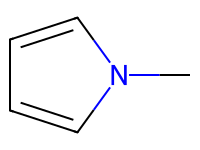
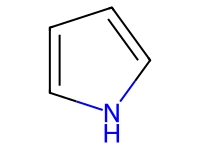
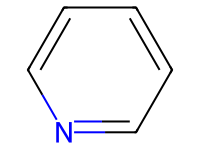
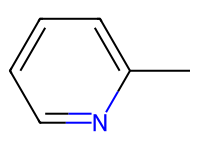
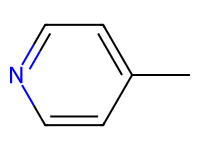
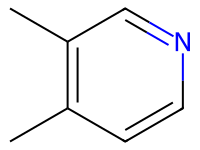
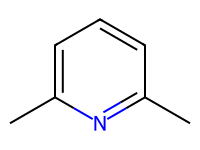
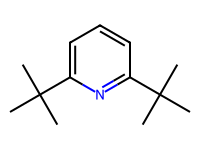
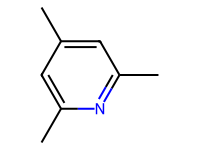
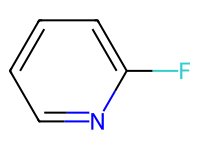
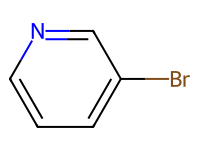
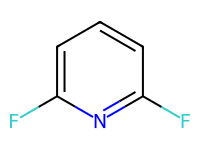
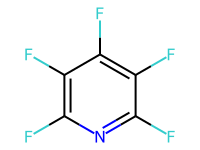
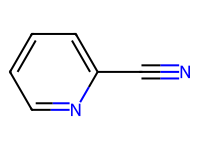

In [14]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools

PandasTools.molSize = (200, 150)


PandasTools.RenderImagesInAllDataFrames(images=True)

file_path = r"C:\Users\pc\Desktop\project\tutorial_rdkit\Heteroaromatics.xlsx"
df = pd.read_excel(file_path)


PandasTools.AddMoleculeColumnToFrame(df, smilesCol='Smiles', molCol='mol')


df

**MACCS Keys**

Uses a predefined dictionary of 167 structural questions (e.g., Has OH? Has Aromatic Ring?).

,Smiles,mol,MACCS_0,MACCS_1,MACCS_2,MACCS_3,MACCS_4,MACCS_5,MACCS_6,MACCS_7,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,CN1C=CC=C1,,0,0,0,0,0,0,0,0,...,0,1,0,1,1,1,0,0,1,0
1,C1=CC=CN1,,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,1,0
2,C1=CN=CC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,1,0
3,CC1=NC=CC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,0,1,0
4,CC1=CC=NC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,0,1,0

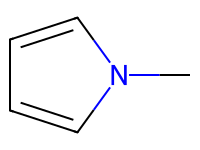
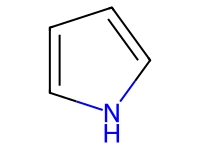
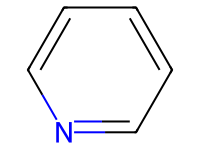
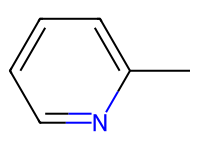
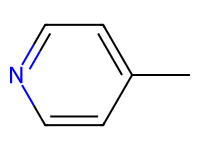

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit import DataStructs

maccs_list = []

for mol in df['mol']:
    if mol is not None:
        
        bv = MACCSkeys.GenMACCSKeys(mol)
        arr = np.zeros((bv.GetNumBits(),), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(bv, arr)
        maccs_list.append(arr)
    else:
        
        maccs_list.append(np.zeros((167,), dtype=np.int8))

maccs_columns = [f'MACCS_{i}' for i in range(167)]
df_maccs = pd.DataFrame(maccs_list, columns=maccs_columns)


MACCS = pd.concat([df, df_maccs], axis=1)


MACCS.head()

**PatternFingerprint**

algo can separate the molecule and their groups for analysis

,Smiles,mol,PF_0,PF_1,PF_2,PF_3,PF_4,PF_5,PF_6,PF_7,...,PF_2038,PF_2039,PF_2040,PF_2041,PF_2042,PF_2043,PF_2044,PF_2045,PF_2046,PF_2047
0,CN1C=CC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,C1=CC=CN1,,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,C1=CN=CC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CC1=NC=CC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CC1=CC=NC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0

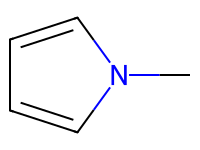
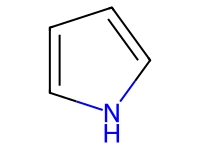
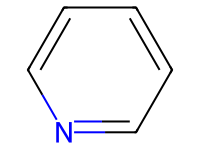
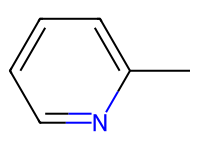
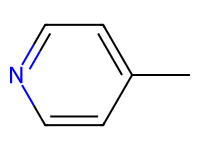

In [21]:
import pandas as pd
import numpy as np
from rdkit import DataStructs
from rdkit.Chem import PatternFingerprint

df_pf = []

for mol in df['mol']:
    if mol is not None:
        fp = PatternFingerprint(mol)
        arr = np.zeros((fp.GetNumBits(),), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(fp, arr)
        df_pf.append(arr)
    else:
        df_pf.append(np.zeros((2048,), dtype=np.int8))  # taille standard du PatternFingerprint

# conversion en DataFrame
df_pf = pd.DataFrame(df_pf, columns=[f'PF_{i}' for i in range(len(df_pf[0]))])

PF = pd.concat([df.reset_index(drop=True), df_pf.reset_index(drop=True)], axis=1)
PF.head()

**Morgan (ECFP4)**
Radius-based scanning: Scans atomic environments in concentric rings around each atom.

[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator
[17:45:58] DEPRECATION WARNING: please use MorganGenerator


,Smiles,mol,MF_0,MF_1,MF_2,MF_3,MF_4,MF_5,MF_6,MF_7,...,MF_2038,MF_2039,MF_2040,MF_2041,MF_2042,MF_2043,MF_2044,MF_2045,MF_2046,MF_2047
0,CN1C=CC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C1=CC=CN1,,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,C1=CN=CC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CC1=NC=CC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CC1=CC=NC=C1,,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0

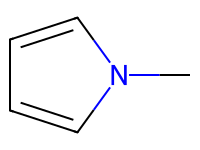
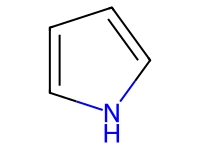
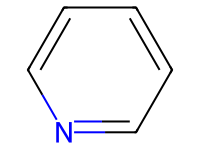
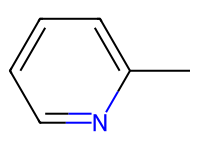
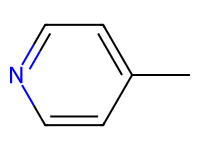

In [41]:
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np
import pandas as pd

df_mf = []

for mol in df['mol']:
    if mol is not None:
        bv = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        arr = np.zeros((bv.GetNumBits(),), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(bv, arr)
        df_mf.append(arr)
    else:
        df_mf.append(np.zeros((2048,), dtype=np.int8))

df_mf = pd.DataFrame(df_mf, columns=[f'MF_{i}' for i in range(len(df_mf[0]))])

MF = pd.concat([df.reset_index(drop=True), df_mf.reset_index(drop=True)], axis=1)
MF.head()

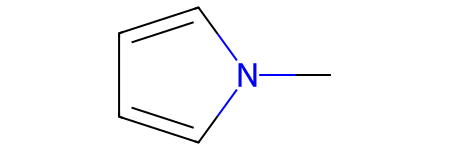

No of ones in the N-methyl pyrrole MF are : 10
No of zeroes in the N-Methyl pyrole MF are : 2038

MF_384     1
MF_637     1
MF_935     1
MF_950     1
MF_1057    1
MF_1088    1
MF_1101    1
MF_1145    1
MF_1619    1
MF_1873    1
Name: 0, dtype: object


In [24]:
display(MF.iloc[0 , 1])#ire les 2 premuieres colonnes 
nmpyrole = MF.iloc[0,2:] #sauter les  2 premieres colonne de dataframe
print(f'No of ones in the N-methyl pyrrole MF are : {nmpyrole[nmpyrole==1].count()}')
print(f'No of zeroes in the N-Methyl pyrole MF are : {nmpyrole[nmpyrole==0].count()}\n')
print(nmpyrole[nmpyrole == 1 ])





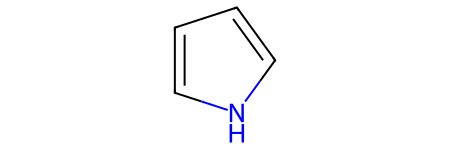

No of ones in the N-Methyl pyrrole MF are: 10 
No of zeros in the N-Methyl pyrrole MF are:  2038 

MF_384     1
MF_637     1
MF_935     1
MF_950     1
MF_1057    1
MF_1088    1
MF_1101    1
MF_1145    1
MF_1619    1
MF_1873    1
Name: 0, dtype: object


In [25]:
display(MF.iloc[1 , 1])
nmpyrole = MF.iloc[0 , 2: ]
print(f'No of ones in the N-Methyl pyrrole MF are: {nmpyrole[nmpyrole == 1].count()} ')
print(f'No of zeros in the N-Methyl pyrrole MF are:  {nmpyrole[nmpyrole==0].count()} \n')
print(nmpyrole[nmpyrole == 1])

      


In [27]:
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np
import pandas as pd




df_ecfp = []
for mol in df['mol']:
  ecfp_bitvector = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits = 2048)
  arr = np.zeros((0,), dtype=np.int8)
  # convert the RDKit explicit vectors into numpy arrays
  DataStructs.ConvertToNumpyArray(ecfp_bitvector,arr)
  df_ecfp.append(arr)

ECFP = pd.concat([df, pd.DataFrame(df_ecfp)], axis=1)
ECFP.head()



[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator
[16:10:01] DEPRECATION WARNING: please use MorganGenerator


,Smiles,mol,0,1,2,3,4,5,6,7,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,CN1C=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x000001251A1...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C1=CC=CN1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,C1=CN=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CC1=NC=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CC1=CC=NC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


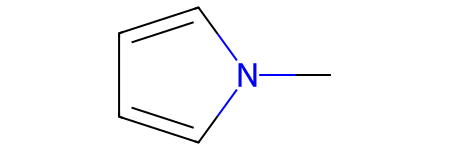

No of ones in the N-Methyl pyrrole ECFP are:  10
No of zeros in the N-Methyl pyrrole ECFP are:  2038 

384     1
637     1
935     1
950     1
1057    1
1088    1
1101    1
1145    1
1619    1
1873    1
Name: 0, dtype: object


In [29]:

# print first molecule in the dataset
display(ECFP.iloc[0,1])
nmpyrrole = ECFP.iloc[0,2:]

# get the number of ones and zeros in the first molecule
print(f'No of ones in the N-Methyl pyrrole ECFP are:  {nmpyrrole[nmpyrrole==1].count()}')
print(f'No of zeros in the N-Methyl pyrrole ECFP are:  {nmpyrrole[nmpyrrole==0].count()} \n')

# grab the column names where bits are 1s
print(nmpyrrole[nmpyrrole==1])


**Avalon algo**

Blends path-based scanning, feature pairs, and predefined structural keys into a single vector.

In [33]:
from rdkit import Chem
from rdkit.Avalon import pyAvalonTools
import numpy as np


df_af = []
for mol in df['mol']:
  af_bitvector = pyAvalonTools.GetAvalonFP(mol, nBits=512)
  arr = np.zeros((0,), dtype=np.int8)
  # convert the RDKit explicit vectors into numpy arrays
  DataStructs.ConvertToNumpyArray(af_bitvector,arr)
  df_af.append(arr)

AF = pd.concat([df, pd.DataFrame(df_af)], axis=1)
AF.head()


,Smiles,mol,0,1,2,3,4,5,6,7,...,502,503,504,505,506,507,508,509,510,511
0,CN1C=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x000001251A1...,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
1,C1=CC=CN1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,0
2,C1=CN=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CC1=NC=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CC1=CC=NC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**RDkit fingerprint**
Traverses the molecule to identify all linear pathways/chains within a bond length range.

,Smiles,mol,RDK_0,RDK_1,RDK_2,RDK_3,RDK_4,RDK_5,RDK_6,RDK_7,...,RDK_4086,RDK_4087,RDK_4088,RDK_4089,RDK_4090,RDK_4091,RDK_4092,RDK_4093,RDK_4094,RDK_4095
0,CN1C=CC=C1,,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C1=CC=CN1,,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,C1=CN=CC=C1,,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CC1=NC=CC=C1,,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CC1=CC=NC=C1,,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0

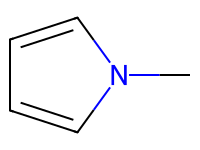
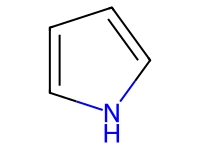
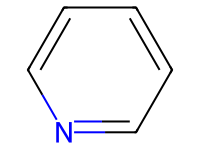
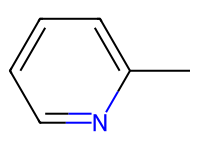
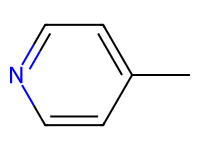

In [34]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs


rdkgen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=4096)

df_rdk = []


for mol in df['mol']:
    if mol is not None:
        # Genere l-Fingerprint
        rdk_bitvector = rdkgen.GetFingerprint(mol)
        arr = np.zeros((4096,), dtype=np.int8)
        DataStructs.ConvertToNumpyArray(rdk_bitvector, arr)
        df_rdk.append(arr)
    else:
 
        df_rdk.append(np.zeros((4096,), dtype=np.int8))


rdk_columns = [f'RDK_{i}' for i in range(4096)]
df_rdk_df = pd.DataFrame(df_rdk, columns=rdk_columns)

RDK = pd.concat([df, df_rdk_df], axis=1)

# 5. Affichage
RDK.head()

**Atom Pair Fingerprint**
Identifies pairs of heavy atoms and calculates the exact bond distance separating them 

In [36]:
from rdkit.Chem.AtomPairs.Pairs import GetAtomPairFingerprintAsBitVect

from rdkit.Chem import rdFingerprintGenerator
df_apf = []
apgen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize= 4096)
for mol in df['mol'] : 
    bv = apgen.GetFingerprint(mol)
    arr = np.array(bv)
    df_apf.append(arr)

APF = pd.concat([df , pd.DataFrame(df_apf)] , axis = 1)
APF.head()


 

,Smiles,mol,0,1,2,3,4,5,6,7,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,CN1C=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x000001251A1...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C1=CC=CN1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,C1=CN=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CC1=NC=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CC1=CC=NC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
# get the number of ones and zeros in the first molecule
print(f'No of ones in the N-Methyl pyrrole ECFP are:  {nmpyrrole[nmpyrrole==1].count()}')
print(f'No of zeros in the N-Methyl pyrrole ECFP are:  {nmpyrrole[nmpyrrole==0].count()} \n')

# grab the column names where bits are 1s
print(nmpyrrole[nmpyrrole==1])

No of ones in the N-Methyl pyrrole ECFP are:  10
No of zeros in the N-Methyl pyrrole ECFP are:  2038 

384     1
637     1
935     1
950     1
1057    1
1088    1
1101    1
1145    1
1619    1
1873    1
Name: 0, dtype: object


**Topological Torsion Fingerprint** 


this ago compute the intraction between each 4 atoms HEAVY (non H)

In [40]:


df_ttf = []
ttgen = rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=2048)
for mol in df['mol']:
  ttf_bitvector = ttgen.GetFingerprint(mol)
  arr = np.array(ttf_bitvector)
  df_ttf.append(arr)

TTF = pd.concat([df, pd.DataFrame(df_ttf)], axis=1)
TTF.head()


,Smiles,mol,0,1,2,3,4,5,6,7,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
0,CN1C=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x000001251A1...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C1=CC=CN1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,C1=CN=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CC1=NC=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CC1=CC=NC=C1,<rdkit.Chem.rdchem.Mol object at 0x00000125195...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
